In [4]:
import pandas as pd
import numpy as np
!dir

 Volume in drive C is OS
 Volume Serial Number is 94E1-0913

 Directory of c:\Users\samsh\Desktop\droneProject\OPEN_BCI

05/01/2026  06:25 PM    <DIR>          .
05/01/2026  06:32 AM    <DIR>          ..
05/01/2026  05:02 PM             9,980 calibrate.py
05/01/2026  06:26 PM    <DIR>          data
05/01/2026  06:06 AM             4,588 eeg_simulator.py
04/30/2026  11:29 PM             1,757 mock_server.py
05/01/2026  05:13 PM             4,468 save_data.py
05/01/2026  06:28 PM            87,835 test.ipynb
04/30/2026  11:29 PM             3,382 test.py
               6 File(s)        112,010 bytes
               3 Dir(s)  584,021,008,384 bytes free


In [6]:
df = pd.read_csv("raw_6.0Hz_10frames_2026-05-01_17-15-06.csv")

Loading data...


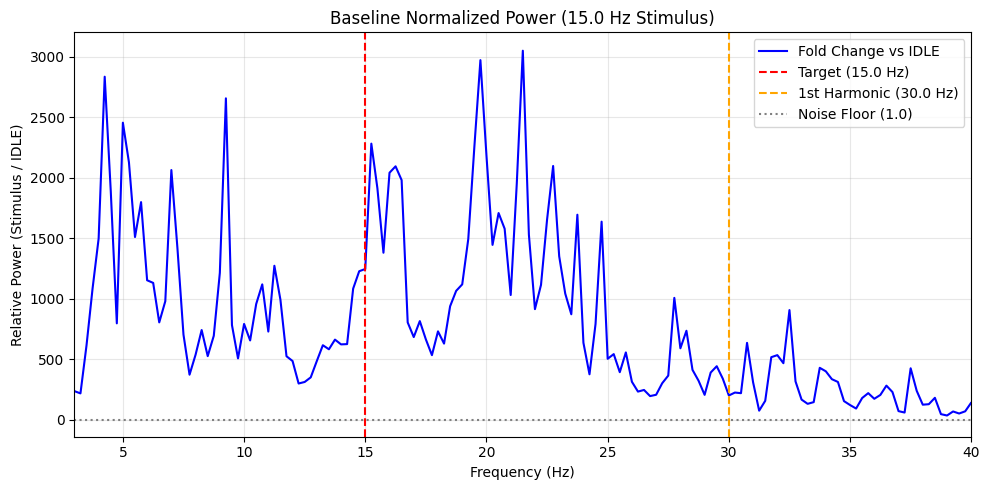

In [30]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
TARGET_FILE = 'data/15.0Hz.csv'
IDLE_FILE = 'data/IDLE.csv'
TARGET_CHANNEL = 'Channel_5' # Choose ONE channel from the back of the head
TARGET_HZ = 15.0
FS = 250.0 # OpenBCI Sampling Rate
# =================================================

def load_and_filter(filepath, channel):
    df = pd.read_csv(filepath)
    # Skip first 3 seconds to let OpenBCI amp settle, take next 30 seconds
    raw_data = df[channel].values[int(FS*3):int(FS*33)]

    # High-pass filter at 2 Hz to remove massive DC baseline drift (sweat/movement)
    b, a = signal.butter(4, 2.0, btype='highpass', fs=FS)
    clean_data = signal.filtfilt(b, a, raw_data)
    return clean_data

# 1. Load and process both files
print("Loading data...")
stim_data = load_and_filter(TARGET_FILE, TARGET_CHANNEL)
idle_data = load_and_filter(IDLE_FILE, TARGET_CHANNEL)

# 2. Calculate Power Spectral Density (PSD) using Welch's method
freqs, stim_power = signal.welch(stim_data, fs=FS, nperseg=FS*4) # 4-second windows for high res
freqs, idle_power = signal.welch(idle_data, fs=FS, nperseg=FS*4)

# 3. Calculate Relative Power (Fold Change)
relative_power = stim_power / idle_power

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(freqs, relative_power, color='blue', linewidth=1.5, label='Fold Change vs IDLE')

# Draw target and harmonic markers
plt.axvline(x=TARGET_HZ, color='red', linestyle='--', label=f'Target ({TARGET_HZ} Hz)')
plt.axvline(x=TARGET_HZ*2, color='orange', linestyle='--', label=f'1st Harmonic ({TARGET_HZ*2} Hz)')

# Formatting
plt.xlim(3, 40) # Focus only on brainwave frequencies
plt.axhline(y=1.0, color='gray', linestyle=':', label='Noise Floor (1.0)')
plt.title(f"Baseline Normalized Power ({TARGET_HZ} Hz Stimulus)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Power (Stimulus / IDLE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

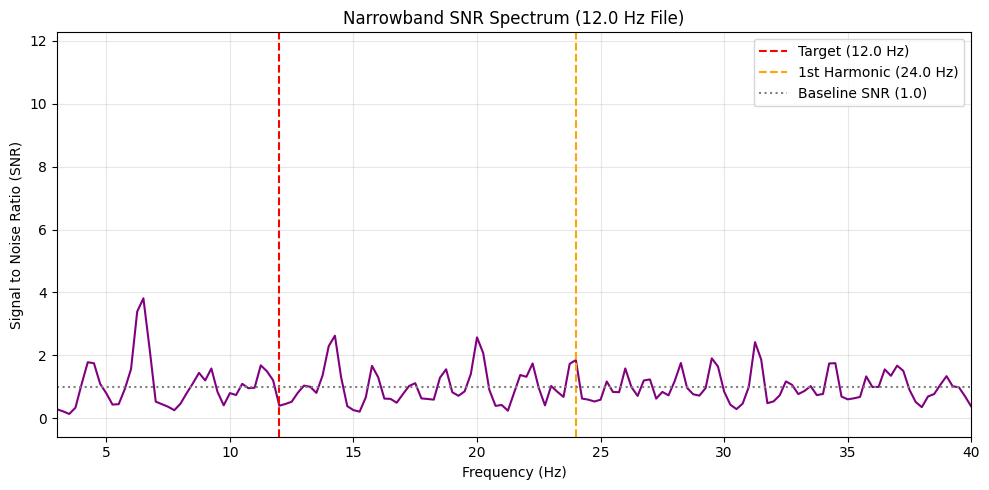

In [38]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
TARGET_FILE = 'data/12.0Hz.csv'
TARGET_CHANNEL = 'Channel_7'
TARGET_HZ = 12.0
FS = 250.0
# =================================================

# 1. Load and Filter Data
df = pd.read_csv(TARGET_FILE)
raw_data = df[TARGET_CHANNEL].values[int(FS*3):] # Skip first 3 seconds
b, a = signal.butter(4, 2.0, btype='highpass', fs=FS)
clean_data = signal.filtfilt(b, a, raw_data)

# 2. Calculate PSD
freqs, power = signal.welch(clean_data, fs=FS, nperseg=1000)

# 3. Calculate Narrowband SNR
snr = np.zeros_like(power)
window_size = 5 # Look 5 bins to the left and right
guard_size = 1  # Skip the immediate adjacent bin to prevent smearing

for i in range(window_size + guard_size, len(power) - window_size - guard_size):
    # Get the power of the neighboring bins (excluding the guard bins)
    noise_bins = np.concatenate([
        power[i - window_size - guard_size : i - guard_size],
        power[i + guard_size + 1 : i + window_size + guard_size + 1]
    ])
    # SNR = target bin power / average of surrounding noise bins
    snr[i] = power[i] / np.mean(noise_bins)

# 4. Plot
plt.figure(figsize=(10, 5))
plt.plot(freqs, snr, color='purple', linewidth=1.5)

plt.axvline(x=TARGET_HZ, color='red', linestyle='--', label=f'Target ({TARGET_HZ} Hz)')
plt.axvline(x=TARGET_HZ*2, color='orange', linestyle='--', label=f'1st Harmonic ({TARGET_HZ*2} Hz)')

plt.xlim(3, 40)
plt.axhline(y=1.0, color='gray', linestyle=':', label='Baseline SNR (1.0)')
plt.title(f"Narrowband SNR Spectrum ({TARGET_HZ} Hz File)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Signal to Noise Ratio (SNR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import numpy as np
from scipy import signal
from sklearn.cross_decomposition import CCA

# ================= CONFIGURATION =================
TARGET_FILE = 'data/15.0Hz.csv'
# Using MULTIPLE back-of-head channels to cancel spatial noise
# CHANNELS = ['Channel_5', 'Channel_6', 'Channel_7']
CHANNELS = ['Channel_2', 'Channel_3', 'Channel_7']
CHECK_FREQUENCIES =[6.0, 7.5, 10.0, 12.0, 15.0, 30.0]
FS = 250.0
# =================================================

# 1. Load multi-channel data
df = pd.read_csv(TARGET_FILE)
eeg_signals =[]

for ch in CHANNELS:
    raw = df[ch].values[int(FS*3):int(FS*15)] # Take 12 seconds of data
    # Filter 2Hz to 40Hz (Remove DC drift and 60Hz powerline noise)
    b, a = signal.butter(4, [2.0, 40.0], btype='bandpass', fs=FS)
    clean = signal.filtfilt(b, a, raw)
    eeg_signals.append(clean)

# X is our EEG matrix: Shape (n_samples, n_channels)
X = np.array(eeg_signals).T
time_array = np.arange(X.shape[0]) / FS

print(f"--- CCA Correlation Scores for file: {TARGET_FILE} ---")
print("Higher score = Higher probability the user is looking at this frequency.\n")

# 2. Test against multiple frequencies using CCA
best_score = 0
predicted_hz = None

for hz in CHECK_FREQUENCIES:
    # Generate perfect Sine/Cosine Reference Signals for Target + 1st Harmonic
    Y = np.vstack([
        np.sin(2 * np.pi * hz * time_array),
        np.cos(2 * np.pi * hz * time_array),
        np.sin(2 * np.pi * (hz * 2) * time_array), # 1st Harmonic
        np.cos(2 * np.pi * (hz * 2) * time_array)
    ]).T

    # Initialize and fit CCA
    cca = CCA(n_components=1)
    X_c, Y_c = cca.fit_transform(X, Y)

    # Calculate Pearson Correlation between transformed EEG and transformed Reference
    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    print(f"Testing {hz:>4} Hz ---> Score: {corr:.4f}")

    if corr > best_score:
        best_score = corr
        predicted_hz = hz

print("\n==============================================")
print(f"RESULT: System predicts the user was looking at {predicted_hz} Hz!")
print("==============================================")

--- CCA Correlation Scores for file: data/15.0Hz.csv ---
Higher score = Higher probability the user is looking at this frequency.

Testing  6.0 Hz ---> Score: 0.1800
Testing  7.5 Hz ---> Score: 0.1606
Testing 10.0 Hz ---> Score: 0.0988
Testing 12.0 Hz ---> Score: 0.0720
Testing 15.0 Hz ---> Score: 0.0761
Testing 30.0 Hz ---> Score: 0.0148

RESULT: System predicts the user was looking at 6.0 Hz!


In [ ]:
import pandas as pd
import numpy as np
from scipy import signal
from sklearn.cross_decomposition import CCA
from itertools import combinations
import time

# ================= CONFIGURATION =================
# We use the 15Hz file as our calibration/search file
TARGET_FILE = 'data/15.0Hz.csv'
TARGET_HZ = 15.0
FS = 250.0

# Using ALL 8 channels
MAX_CHANNELS_IN_COMBO = 8
# =================================================

print(f"Loading {TARGET_FILE} and pre-filtering data...")

# 1. Load Data
df = pd.read_csv(TARGET_FILE)
all_channels =[f'Channel_{i}' for i in range(8)]

# 2. Pre-filter all channels to save processing time
filtered_data = {}
for ch in all_channels:
    # Skip first 3 seconds (amp settling) and take the next 12 seconds
    raw = df[ch].values[int(FS*3):int(FS*15)]
    b, a = signal.butter(4, 2.0, btype='highpass', fs=FS)
    filtered_data[ch] = signal.filtfilt(b, a, raw)

time_array = np.arange(len(raw)) / FS

# 3. Build the "Perfect" Reference Signals (Y)
Y = np.vstack([
    np.sin(2 * np.pi * TARGET_HZ * time_array),
    np.cos(2 * np.pi * TARGET_HZ * time_array),
    np.sin(2 * np.pi * (TARGET_HZ * 2) * time_array),
    np.cos(2 * np.pi * (TARGET_HZ * 2) * time_array)
]).T

print("Running all 255 channel combinations...")
start_time = time.time()

# 4. Iterate through ALL combinations of channels (1 to 8)
results =[]

for combo_length in range(1, MAX_CHANNELS_IN_COMBO + 1):
    for combo in combinations(all_channels, combo_length):

        # Stack the selected channels into our X matrix
        X = np.column_stack([filtered_data[c] for c in combo])

        # Initialize and run CCA
        cca = CCA(n_components=1)
        X_c, Y_c = cca.fit_transform(X, Y)

        # Calculate Pearson Correlation score
        corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

        results.append({
            'channels': combo,
            'score': corr,
            'count': combo_length
        })

end_time = time.time()

# 5. Sort the results by the highest correlation score
results.sort(key=lambda x: x['score'], reverse=True)

# 6. Display the Leaderboard
print(f"\nCompleted in {(end_time - start_time):.3f} seconds!\n")
print("=== TOP 20 CHANNEL COMBINATIONS (Out of 255) ===")
print(f"Target Frequency: {TARGET_HZ} Hz\n")
print(f"{'Rank':<5} | {'Score':<8} | {'# Chs':<5} | {'Channels'}")
print("-" * 100)

for i, res in enumerate(results[:20]):
    # Formatting the tuple for clean printing
    ch_str = ", ".join([ch.replace("Channel_", "Ch") for ch in res['channels']])
    print(f"{i+1:<5} | {res['score']:.4f}   |   {res['count']:<3} | {ch_str}")

Loading data/15.0Hz.csv and sweeping channel configurations...

=== TOP 15 CHANNEL COMBINATIONS ===
Target Frequency: 15.0 Hz

Rank  | Score    | # Chs | Channels
-------------------------------------------------------
1     | 0.0729   |   3   | Channel_2, Channel_3, Channel_7
2     | 0.0729   |   3   | Channel_1, Channel_2, Channel_3
3     | 0.0726   |   3   | Channel_1, Channel_3, Channel_7
4     | 0.0725   |   3   | Channel_1, Channel_2, Channel_7
5     | 0.0700   |   3   | Channel_2, Channel_6, Channel_7
6     | 0.0699   |   3   | Channel_2, Channel_5, Channel_7
7     | 0.0696   |   3   | Channel_2, Channel_4, Channel_7
8     | 0.0696   |   3   | Channel_0, Channel_2, Channel_7
9     | 0.0695   |   2   | Channel_2, Channel_7
10    | 0.0684   |   3   | Channel_2, Channel_3, Channel_5
11    | 0.0681   |   3   | Channel_2, Channel_3, Channel_6
12    | 0.0680   |   3   | Channel_3, Channel_5, Channel_7
13    | 0.0679   |   3   | Channel_1, Channel_3, Channel_6
14    | 0.0678   |   3   